# k-Community Detection on IBM Quantum Hardware

This notebook runs the **Layer-VQE** algorithm for **k-community detection**
(modularity maximisation) on real IBM quantum hardware — or a local
noise-model fake backend for testing.

The problem is introduced in Liu et al. (2022), Section V.  The goal is to
partition the n nodes of a graph into k communities so that the
**Newman-Girvan modularity** Q is maximised.

## How `src/` primitives map to IBM Runtime

| `src/` primitive | Role here |
|---|---|
| `CommunityDetection` | Problem: modularity matrix B, Hamiltonian terms, brute-force oracle |
| `Ansatz` | Parameterised circuit template (converted to Qiskit) |
| `COBYLA` / `SMO` | Classical outer optimiser |
| `LayerVQE` | Layer-by-layer optimisation orchestrator |
| **IBM `Estimator`** | Replaces `QuimbSimulator.expectation()` on hardware |
| **IBM `Sampler`** | Replaces `QuimbSimulator.sample_expectation()` for solution decoding |

## Qubit-frugal encoding (Liu et al. §V, eq. 12)

For **k communities** each node v is assigned N = ⌈log₂k⌉ binary qubits,
encoding the community label as:

$$c_v = \sum_{j=0}^{N-1} 2^{j}\, x_{j,v}, \qquad x_{j,v} \in \{0,1\}$$

Qubit layout: qubit `j * n_nodes + v` carries bit j of node v's label.
Total qubits required: **n · N** (vs kn for the naive one-hot encoding).

| k | N | Qubits (6-node graph) |
|---|---|---|
| 2 | 1 | 6 |
| 4 | 2 | 12 |
| 8 | 3 | 18 |

The Hamiltonian (eq. 12) is:

$$\mathcal{H} = -\frac{1}{2m}\sum_{u,v} B_{u,v} \prod_{j=1}^{N} \frac{I + Z_{j,u} Z_{j,v}}{2}$$

For k=2 (N=1) this reduces to a **2-body** ZZ Hamiltonian.  For k=4 (N=2)
it introduces **4-body** ZZZZ terms.

## Credentials setup

```
# .env  (gitignored — never commit this file)
IBM_QUANTUM_TOKEN=your_token_here
IBM_QUANTUM_INSTANCE=          # CRN; blank = service default
USE_REAL_HARDWARE=false
```

Copy `.env.example` → `.env` and fill in your token.


In [1]:
# Uncomment to install missing packages
# !pip install qiskit-ibm-runtime python-dotenv
# !pip install qiskit-aer       # required for Scenario 3 (Aer noise model)


In [2]:
import sys, os, time, threading
from pathlib import Path
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from dotenv import load_dotenv

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
load_dotenv(PROJECT_ROOT / '.env')

from src.community_detection import CommunityDetection
from src.ansatze import Ansatz
from src.optimizer import COBYLA, SMO
from src.lvqe import LayerVQE

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import (
    QiskitRuntimeService, Batch,
    EstimatorV2 as Estimator, SamplerV2 as Sampler,
)

try:
    from qiskit_aer import AerSimulator
    HAS_AER = True
except ImportError:
    HAS_AER = False
    print("qiskit-aer not found -- Scenario 3 (Aer noise model) will be skipped.")

print('All imports OK')


All imports OK


## Configuration


In [3]:
IBM_TOKEN    = os.getenv("IBM_QUANTUM_TOKEN",    "").strip()
IBM_INSTANCE = os.getenv("IBM_QUANTUM_INSTANCE", "").strip()
USE_REAL_HARDWARE = os.getenv("USE_REAL_HARDWARE", "false").lower() == "true"

SEED      = 42
K         = 2
N_LAYERS  = 2
# COBYLA needs at least (num_params + 2) evaluations per layer to build its
# simplex.  With 10 qubits, layer 1 has 46 params -> min 48 evals needed.
# Setting K_PER_LAYER = 100 avoids the scipy auto-correction warning and gives
# COBYLA enough room to make meaningful progress on intermediate layers.
K_PER_LAYER = 100
K_FINAL     = 300
OPTIMIZER   = COBYLA

print(f"USE_REAL_HARDWARE : {USE_REAL_HARDWARE}")
print(f"IBM_TOKEN present : {'yes' if IBM_TOKEN else 'no -- will use fake backend'}")
if IBM_INSTANCE:
    print(f"IBM_INSTANCE      : {IBM_INSTANCE}")


USE_REAL_HARDWARE : True
IBM_TOKEN present : yes


## Problem: k-Community Detection on a larger graph

We use a **planted-partition graph** with **2 communities of 5 nodes** (10 nodes total).
With k=2 and N=1 bit per node this requires **10 qubits** — large enough that hardware
noise meaningfully affects the learning dynamics, but still tractable on open-plan devices.

The graph is generated with `nx.planted_partition_graph(2, 5, p_in, p_out)`:
- `p_in = 0.9`: high intra-community edge density (clear structure)
- `p_out = 0.05`: sparse inter-community edges (some noise / realism)

All three experimental scenarios run on this same problem so results are directly comparable.


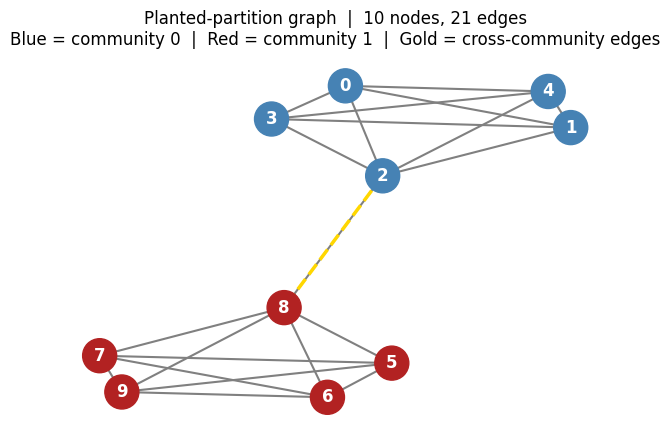

Nodes              : 10
Edges              : 21
k communities      : 2
N bits / node      : 1
Qubits             : 10
Hamiltonian terms  : 46
Best modularity Q  : 0.4524
Best energy        : -0.4524

Qubit layout  (qubit q -> bit j of node v):
  qubit  0  ->  bit 0 of node 0  (community 0)
  qubit  1  ->  bit 0 of node 1  (community 0)
  qubit  2  ->  bit 0 of node 2  (community 0)
  qubit  3  ->  bit 0 of node 3  (community 0)
  qubit  4  ->  bit 0 of node 4  (community 0)
  qubit  5  ->  bit 0 of node 5  (community 1)
  qubit  6  ->  bit 0 of node 6  (community 1)
  qubit  7  ->  bit 0 of node 7  (community 1)
  qubit  8  ->  bit 0 of node 8  (community 1)
  qubit  9  ->  bit 0 of node 9  (community 1)


In [4]:
np.random.seed(SEED)

# Planted partition: 2 communities of 5 nodes each
# Nodes 0-4 -> community 0 | Nodes 5-9 -> community 1
G = nx.planted_partition_graph(2, 5, 0.9, 0.05, seed=SEED)

COMMUNITY_COLORS = ['steelblue', 'firebrick', 'seagreen', 'darkorange']
expected = [0]*5 + [1]*5

fig, ax = plt.subplots(figsize=(6, 4.5))
pos = nx.spring_layout(G, seed=SEED)
nx.draw(
    G, pos, ax=ax, with_labels=True,
    node_color=[COMMUNITY_COLORS[c] for c in expected],
    node_size=600, font_color='white', font_weight='bold',
    edge_color='gray', width=1.5,
)
cross = [(u, v) for u, v in G.edges() if expected[u] != expected[v]]
nx.draw_networkx_edges(G, pos, edgelist=cross, ax=ax,
                       edge_color='gold', width=2.5, style='dashed')
ax.set_title(
    f'Planted-partition graph  |  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n'
    f'Blue = community 0  |  Red = community 1  |  Gold = cross-community edges'
)
plt.tight_layout()
plt.show()

problem = CommunityDetection(G, k=K, seed=SEED)
N_BITS  = problem.N

print(f'Nodes              : {problem.num_nodes}')
print(f'Edges              : {problem.num_edges}')
print(f'k communities      : {K}')
print(f'N bits / node      : {N_BITS}')
print(f'Qubits             : {problem.num_qubits}')
print(f'Hamiltonian terms  : {len(problem.hamiltonian_terms)}')
Q_best = -problem.best_known_value
print(f'Best modularity Q  : {Q_best:.4f}')
print(f'Best energy        : {problem.best_known_value:.4f}')
print()
print('Qubit layout  (qubit q -> bit j of node v):')
for q in range(problem.num_qubits):
    j = q // problem.num_nodes
    v = q %  problem.num_nodes
    print(f'  qubit {q:2d}  ->  bit {j} of node {v}  (community {expected[v]})')


## Translate `Ansatz` → Qiskit `QuantumCircuit`

`Ansatz.get_gates(params)` accepts any indexable sequence of angles.
Passing a `ParameterVector` instead of a NumPy array yields a fully symbolic
Qiskit circuit that can be transpiled once and evaluated many times.

This function is identical to the one used in the MaxCut notebook — the ansatz
structure is problem-agnostic.


In [5]:
def ansatz_to_qiskit(ansatz: Ansatz):
    """
    Convert an Ansatz to a parameterized Qiskit QuantumCircuit.

    Passes a ParameterVector directly into Ansatz.get_gates(), which returns
    gate tuples whose angle slots hold Parameter objects rather than floats.
    Qiskit's `ry` gate accepts Parameter objects natively.

    Returns
    -------
    qc    : QuantumCircuit  (parameterized)
    theta : ParameterVector (same length as ansatz.param_count())
    """
    n     = ansatz.n_qubits
    theta = ParameterVector('theta', ansatz.param_count())
    qc    = QuantumCircuit(n)
    for gate in ansatz.get_gates(theta):
        if gate[0] == 'Ry':
            _, qubit, angle = gate
            qc.ry(angle, qubit)
        elif gate[0] == 'CNOT':
            _, control, target = gate
            qc.cx(control, target)
    return qc, theta


Qubits     : 10
Parameters : 82
Depth      : 17


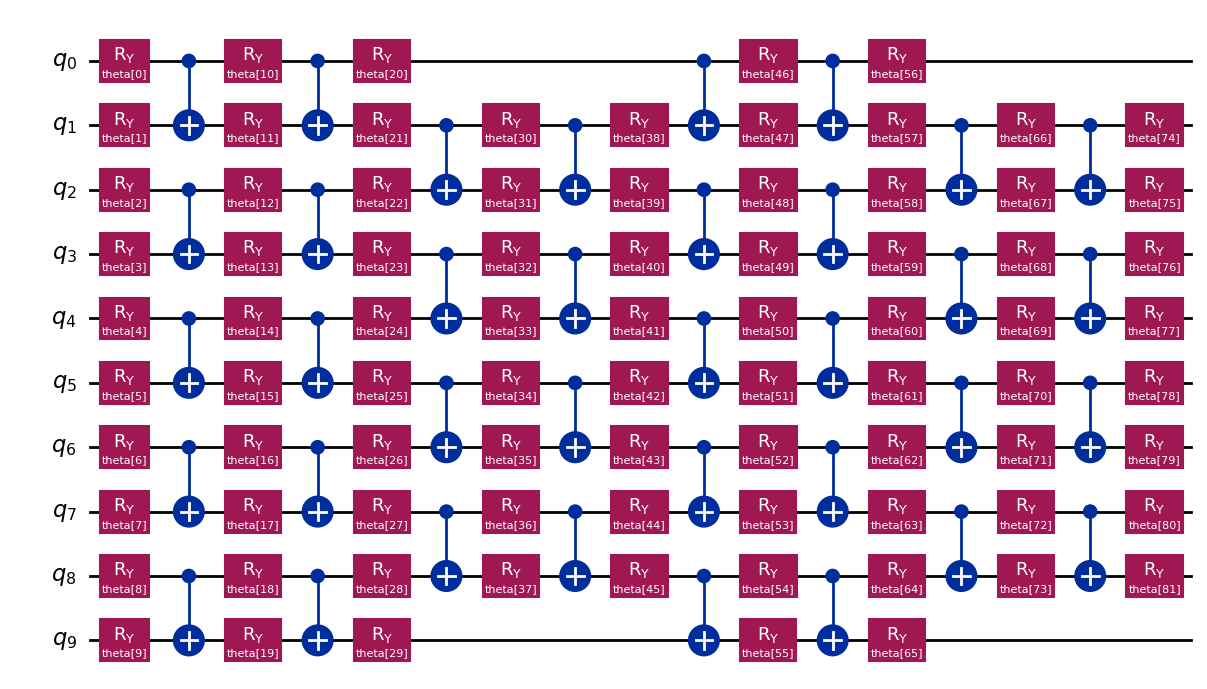

In [6]:
# Build a fresh Ansatz with N_LAYERS extra layers
demo_ansatz = Ansatz(problem.num_qubits)
for _ in range(N_LAYERS):
    demo_ansatz.add_layer()

qc_demo, theta_demo = ansatz_to_qiskit(demo_ansatz)
print(f'Qubits     : {qc_demo.num_qubits}')
print(f'Parameters : {demo_ansatz.param_count()}')
print(f'Depth      : {qc_demo.depth()}')
qc_demo.draw('mpl', fold=-1, style='iqp')


## Translate `problem.hamiltonian_terms` → `SparsePauliOp`

Each Hamiltonian term `(coeff, [q1, q2, ...])` is a product of Z operators.
Qiskit uses **little-endian** Pauli strings: qubit 0 is the **rightmost** character.

For k=2 (N=1) all terms are at most 2-body (ZZ or I), identical in structure to
the MaxCut Hamiltonian.  For k=4 (N=2) the expansion of
$\prod_{j=1}^{2}(I + Z_{j,u}Z_{j,v})/2$ introduces **4-body** ZZZZ terms — still
handled by the same conversion function below.


In [7]:
def hamiltonian_to_sparse_pauli(problem) -> SparsePauliOp:
    """
    Build a SparsePauliOp from problem.hamiltonian_terms.

    Works for any Problem subclass whose hamiltonian_terms follow the
    [(coeff, [qubit_indices, ...]), ...] convention.
    Qiskit Pauli strings are little-endian: qubit q lives at position (n - 1 - q).
    """
    n         = problem.num_qubits
    pauli_list = []
    for coeff, qubits in problem.hamiltonian_terms:
        chars = ['I'] * n
        for q in qubits:
            chars[n - 1 - q] = 'Z'
        pauli_list.append((''.join(chars), coeff))
    return SparsePauliOp.from_list(pauli_list)


observable = hamiltonian_to_sparse_pauli(problem)
print(f'SparsePauliOp: {len(observable)} terms')
# Show first few terms to verify structure
print('\nFirst 10 terms:')
for term in list(observable)[:10]:
    print(f'  {term.coeffs[0].real:+.5f}  x  {term.paulis[0]}')
if len(observable) > 10:
    print(f'  ... ({len(observable) - 10} more terms)')


SparsePauliOp: 46 terms

First 10 terms:
  +0.05045  x  IIIIIIIIII
  -0.01474  x  IIIIIIIIZZ
  -0.01247  x  IIIIIIIZIZ
  -0.01474  x  IIIIIIZIIZ
  -0.01474  x  IIIIIZIIIZ
  +0.00907  x  IIIIZIIIIZ
  +0.00907  x  IIIZIIIIIZ
  +0.00907  x  IIZIIIIIIZ
  +0.01134  x  IZIIIIIIIZ
  +0.00907  x  ZIIIIIIIIZ
  ... (36 more terms)


## Experimental Scenarios: Hardware Noise Analysis

We run L-VQE under three different noise conditions to study how hardware noise
affects the optimisation dynamics.

| # | Scenario | Backend | Noise type |
|---|---|---|---|
| 1 | **Real Hardware** | IBM Quantum device (`least_busy`) | Physical hardware noise |
| 2 | **IBM Fake Backend** | `FakeGuadalupeV2` via IBM Runtime | Pauli-error noise model from calibration |
| 3 | **Aer Noise Model** | `AerSimulator.from_backend(FakeGuadalupeV2)` | T1/T2 + gate + readout noise |

Scenarios 2 and 3 use the same device calibration data but different simulation engines.
Scenario 1 adds any real, time-varying hardware noise on top of that.


> **Authentication note:** `IBMEstimatorBackend` handles authentication
> internally. It calls `QiskitRuntimeService(channel='ibm_quantum_platform', token=IBM_TOKEN, instance=IBM_INSTANCE)`
> directly from the environment variables set in `.env`. No `save_account` call is needed.


In [8]:
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2
NOISE_REFERENCE_BACKEND = FakeGuadalupeV2()

if USE_REAL_HARDWARE and IBM_TOKEN:
    try:
        _svc_kwargs = dict(channel='ibm_quantum_platform', token=IBM_TOKEN)
        if IBM_INSTANCE:
            _svc_kwargs['instance'] = IBM_INSTANCE
        _svc = QiskitRuntimeService(**_svc_kwargs)
        _hw_preview = _svc.least_busy(
            operational=True, simulator=False, min_num_qubits=problem.num_qubits
        )
        print(f'Real backend preview : {_hw_preview.name}  ({_hw_preview.num_qubits} qubits)')
    except Exception as _e:
        print(f'Could not preview real backend ({_e})')
else:
    print('USE_REAL_HARDWARE=false or no token -- Scenario 1 will be skipped.')


qiskit_runtime_service._discover_account:WARNING:2026-06-11 21:42:32,429: Loading account with the given token. A saved account will not be used.


Could not preview real backend ('No matching instances found for the following filters: .')


## Circuit Complexity Preview

Transpile the demo ansatz (Layer 0 + N_LAYERS) onto `FakeGuadalupeV2` to get
a realistic picture of how deep the circuits will be under hardware noise.


In [ ]:
_pm_preview = generate_preset_pass_manager(backend=NOISE_REFERENCE_BACKEND, optimization_level=1)
_isa_preview = _pm_preview.run(qc_demo)

print(f'Backend             : {NOISE_REFERENCE_BACKEND.name}  ({NOISE_REFERENCE_BACKEND.num_qubits} qubits)')
print(f'Problem qubits      : {problem.num_qubits}')
print(f'Original depth      : {qc_demo.depth()}')
print(f'Transpiled depth    : {_isa_preview.depth()}')
print(f'2Q gate count       : {_isa_preview.num_nonlocal_gates()}')
print()
print('Note: more 2Q gates -> more noise -> larger gap between noiseless and hardware results.')


## Backend Classes

Three classes expose the same `.expectation(params, ansatz, problem)` interface
to `LayerVQE`:

| Class | Scenario | Description |
|---|---|---|
| `IBMEstimatorBackend` | 1 (hardware) and 2 (fake) | Multi-token, batch-aware IBM Runtime backend |
| `AerNoiseBackend` | 3 (Aer noise model) | `AerSimulator` with T1/T2 + gate + readout noise |

`IBMEstimatorBackend` with `token_configs=[]` starts on the fake backend directly
(Scenario 2). With a non-empty `token_configs` it uses real hardware and falls back
to fake when tokens are exhausted (Scenario 1).


In [ ]:
# ── IBMEstimatorBackend ────────────────────────────────────────────────────────
class IBMEstimatorBackend:
    '''
    Single-token IBM Quantum Runtime backend for L-VQE.

    Handles:
    - Batch lifecycle with periodic rotation to prevent session expiry
    - Thread-based timeouts on Batch open / close so a hung IBM service
      does NOT freeze the notebook (the fix for the previous stall)
    - Job result timeout with automatic fallback to local fake backend
    - Consecutive-failure fallback: after `fallback_after` failures the
      backend permanently switches to the fake device
    '''

    def __init__(self, token, instance, min_qubits, observable,
                 shots=1024, batch_budget_sec=480.0, max_batch_rotations=3,
                 fallback_backend=None, pm_builder=None, fallback_after=2,
                 result_timeout_sec=300.0, mode_open_timeout_sec=60.0):
        self._token             = (token or "").strip()
        self._instance          = (instance or "").strip()
        self._min_qubits        = min_qubits
        self._obs               = observable
        self._shots             = shots
        self._batch_budget      = batch_budget_sec
        self._max_rotations     = max_batch_rotations
        self._fb_backend        = fallback_backend
        self._pm_builder        = pm_builder or (
            lambda bk: generate_preset_pass_manager(backend=bk, optimization_level=1)
        )
        self._fallback_after    = fallback_after
        self._result_timeout    = result_timeout_sec
        self._mode_open_timeout = mode_open_timeout_sec

        self._cache       = {}
        self._on_fake     = False
        self._consec_fail = 0
        self._n_rotations = 0
        self._eval_count  = 0
        self._switch_eval = None
        self._batch_start = 0.0
        self._mode        = None
        self._est         = None
        self._pm          = None

        if not self._token:
            self._init_fake_direct()
        else:
            self._init_hardware()

    # ── Init ──────────────────────────────────────────────────────────────────

    def _init_hardware(self):
        try:
            svc_kwargs = dict(channel="ibm_quantum_platform", token=self._token)
            if self._instance:
                svc_kwargs["instance"] = self._instance
            service = QiskitRuntimeService(**svc_kwargs)
            backend = service.least_busy(
                operational=True, simulator=False, min_num_qubits=self._min_qubits
            )
            self._current_backend = backend
            self._pm              = self._pm_builder(backend)
            bk = backend  # captured by value; safe when backend ref changes
            self._make_mode   = lambda: Batch(backend=bk)
            self._consec_fail = 0
            self._open_new_mode()
            print(f"  Connected to {backend.name}  ({backend.num_qubits} qubits)")
        except Exception as exc:
            self._switch_to_fake(reason=str(exc))

    def _init_fake_direct(self):
        self._on_fake = True
        self._pm      = self._pm_builder(self._fb_backend)
        self._mode    = self._fb_backend
        self._est     = Estimator(mode=self._fb_backend)
        self._est.options.default_shots = self._shots
        print("  IBMEstimatorBackend: no token -> running on local fake backend.")

    # ── Mode lifecycle with hang-prevention ───────────────────────────────────

    def _timed_call(self, fn, timeout_sec, label="operation"):
        '''
        Run fn() in a daemon thread; raise RuntimeError if it exceeds
        timeout_sec. This prevents Batch() / mode.__exit__() from
        blocking indefinitely when IBM service is unresponsive.
        The daemon thread is abandoned (not killed) but the main thread
        is free to proceed (fall back to fake, etc.).
        '''
        result_box = [None]
        error_box  = [None]

        def _run():
            try:
                result_box[0] = fn()
            except Exception as exc:
                error_box[0] = exc

        t = threading.Thread(target=_run, daemon=True)
        t.start()
        t.join(timeout=timeout_sec)

        if t.is_alive():
            raise RuntimeError(
                f"Timed out during '{label}' after {timeout_sec:.0f}s — "
                "IBM service appears unresponsive."
            )
        if error_box[0] is not None:
            raise error_box[0]
        return result_box[0]

    def _open_new_mode(self):
        '''Open a new Batch with a thread-based timeout to prevent hanging.'''
        self._mode = self._timed_call(
            self._make_mode, self._mode_open_timeout, label="Batch open"
        )
        self._est  = Estimator(mode=self._mode)
        self._est.options.default_shots = self._shots
        self._batch_start  = time.time()
        self._n_rotations += 1

    def _close_mode(self):
        '''Close the current Batch safely with a 30s timeout.'''
        if self._mode is None or self._on_fake:
            return
        try:
            mode = self._mode
            self._timed_call(
                lambda: mode.__exit__(None, None, None),
                timeout_sec=30.0,
                label="Batch close",
            )
        except Exception:
            pass  # best-effort; don't let close failures crash the run
        finally:
            self._mode = None

    def _rotate_batch(self):
        '''Close the current Batch and open a fresh one to reset the session clock.'''
        if self._n_rotations >= self._max_rotations:
            self._switch_to_fake(reason="max batch rotations reached")
            return
        print(f"\n  [BATCH ROTATE] opening rotation {self._n_rotations + 1}/{self._max_rotations}")
        try:
            self._close_mode()
            self._cache.clear()  # layouts are backend-specific; must re-transpile
            self._open_new_mode()
        except Exception as exc:
            self._switch_to_fake(reason=f"batch rotation failed: {exc}")

    def _switch_to_fake(self, reason=""):
        '''Permanently fall back to the local fake backend.'''
        self._close_mode()
        self._cache.clear()
        self._on_fake     = True
        self._switch_eval = self._eval_count
        self._pm   = self._pm_builder(self._fb_backend)
        self._mode = self._fb_backend
        self._est  = Estimator(mode=self._fb_backend)
        self._est.options.default_shots = self._shots
        print(f"\n{'='*70}")
        print(f"  [FALLBACK] switching to local fake backend.")
        print(f"             reason: {reason!r}")
        print(f"             remaining results come from a NOISY LOCAL SIM.")
        print(f"{'='*70}\n")

    # ── ISA cache ──────────────────────────────────────────────────────────────

    def _get_isa(self, ansatz):
        key = (ansatz.n_layers, ansatz.n_qubits, ansatz.param_count())
        if key not in self._cache:
            qc, _   = ansatz_to_qiskit(ansatz)
            isa_qc  = self._pm.run(qc)
            isa_obs = self._obs.apply_layout(isa_qc.layout)
            self._cache[key] = (isa_qc, isa_obs)
        return self._cache[key]

    # ── Core interface ─────────────────────────────────────────────────────────

    def expectation(self, params, ansatz, problem) -> float:
        self._eval_count += 1

        # Rotate the Batch before the session window closes
        if not self._on_fake and (time.time() - self._batch_start) > self._batch_budget:
            self._rotate_batch()

        isa_qc, isa_obs = self._get_isa(ansatz)

        try:
            job = self._est.run([(isa_qc, isa_obs, params)])

            if self._on_fake:
                result = job.result()
            else:
                try:
                    result = job.result(timeout=self._result_timeout)
                except Exception as timeout_exc:
                    self._consec_fail += 1
                    if self._consec_fail >= self._fallback_after:
                        self._switch_to_fake(reason=str(timeout_exc))
                        isa_qc, isa_obs = self._get_isa(ansatz)
                        result = self._est.run([(isa_qc, isa_obs, params)]).result()
                    else:
                        raise

            self._consec_fail = 0
            return float(result[0].data.evs)

        except Exception as exc:
            if not self._on_fake:
                self._consec_fail += 1
                if self._consec_fail >= self._fallback_after:
                    self._switch_to_fake(reason=str(exc))
                    isa_qc, isa_obs = self._get_isa(ansatz)
                    return float(
                        self._est.run([(isa_qc, isa_obs, params)]).result()[0].data.evs
                    )
            raise

    def sample_expectation(self, params, ansatz, problem, n_samples=1024) -> float:
        if n_samples != self._shots:
            self._shots = n_samples
            self._est.options.default_shots = n_samples
        return self.expectation(params, ansatz, problem)

    @property
    def on_fake(self):
        return self._on_fake

    def close(self):
        self._close_mode()

    def summary(self):
        if self._switch_eval is not None:
            print(f"  Backend switch : hardware -> fake at eval "
                  f"{self._switch_eval}/{self._eval_count}")
        else:
            mode = "fake (no token)" if self._on_fake else "real hardware"
            print(f"  Backend        : {mode}  ({self._eval_count} evaluations)")


# ── AerNoiseBackend ────────────────────────────────────────────────────────────
class AerNoiseBackend:
    '''
    Scenario 3: AerSimulator with a full hardware noise model.
    Extracts T1/T2, gate errors and readout errors from the fake backend
    calibration data via AerSimulator.from_backend().
    '''

    def __init__(self, source_backend, observable, shots=1024, optimization_level=1):
        if not HAS_AER:
            raise ImportError("qiskit-aer required. Install: pip install qiskit-aer")
        self._sim  = AerSimulator.from_backend(source_backend)
        self._pm   = generate_preset_pass_manager(
            backend=self._sim, optimization_level=optimization_level
        )
        self._obs   = observable
        self._shots = shots
        self._est   = Estimator(mode=self._sim)
        self._est.options.default_shots = shots
        self._cache = {}
        print(f"  AerNoiseBackend: noise model from '{source_backend.name}'  "
              f"({source_backend.num_qubits} qubits, shots={shots})")

    def _get_isa(self, ansatz):
        key = (ansatz.n_layers, ansatz.n_qubits, ansatz.param_count())
        if key not in self._cache:
            qc, _   = ansatz_to_qiskit(ansatz)
            isa_qc  = self._pm.run(qc)
            isa_obs = self._obs.apply_layout(isa_qc.layout)
            self._cache[key] = (isa_qc, isa_obs)
        return self._cache[key]

    def expectation(self, params, ansatz, problem) -> float:
        isa_qc, isa_obs = self._get_isa(ansatz)
        return float(self._est.run([(isa_qc, isa_obs, params)]).result()[0].data.evs)

    def sample_expectation(self, params, ansatz, problem, n_samples=1024) -> float:
        if n_samples != self._shots:
            self._shots = n_samples
            self._est.options.default_shots = n_samples
        return self.expectation(params, ansatz, problem)

    @property
    def on_fake(self):
        return False

    def close(self):
        pass


## Run All Scenarios

Each scenario runs L-VQE with identical hyperparameters on the same problem.
Results are stored in `all_results` for comparison.

| Scenario | When run |
|---|---|
| Real Hardware | Only when `USE_REAL_HARDWARE=true` and tokens are available |
| Fake Backend | Always |
| Aer Noise Model | When `qiskit-aer` is installed |

> **Runtime estimate:** Fake backend ~2-5 min, Aer noise model ~5-15 min,
> Real hardware depends on queue and token budget.


In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2

def build_pm(bk):
    return generate_preset_pass_manager(backend=bk, optimization_level=1)

SCENARIOS = {}

# -- Scenario 1: Real Hardware ------------------------------------------------
if USE_REAL_HARDWARE and IBM_TOKEN:
    SCENARIOS["Real Hardware"] = IBMEstimatorBackend(
        token                 = IBM_TOKEN,
        instance              = IBM_INSTANCE,
        min_qubits            = problem.num_qubits,
        observable            = observable,
        shots                 = 1024,
        batch_budget_sec      = 480.0,
        max_batch_rotations   = 3,
        fallback_backend      = FakeGuadalupeV2(),
        pm_builder            = build_pm,
        fallback_after        = 2,
        result_timeout_sec    = 300.0,
        mode_open_timeout_sec = 60.0,   # Batch open/close fails fast after 60s
    )
else:
    print("Scenario 1 (Real Hardware) skipped.")

# -- Scenario 2: IBM Fake Backend ---------------------------------------------
SCENARIOS["Fake Backend"] = IBMEstimatorBackend(
    token            = "",           # empty -> starts on fake directly
    instance         = "",
    min_qubits       = problem.num_qubits,
    observable       = observable,
    shots            = 1024,
    fallback_backend = FakeGuadalupeV2(),
    pm_builder       = build_pm,
)

# -- Scenario 3: Aer Noise Model ----------------------------------------------
if HAS_AER:
    SCENARIOS["Aer Noise Model"] = AerNoiseBackend(
        source_backend = FakeGuadalupeV2(),
        observable     = observable,
        shots          = 2048,
    )
else:
    print("Scenario 3 skipped -- install qiskit-aer.")

print(f"\nRunning {len(SCENARIOS)} scenario(s): {list(SCENARIOS.keys())}")

# --------------------------------------------------------------------------
all_results = {}

for scenario_name, sim in SCENARIOS.items():
    print(f"\n{'='*65}")
    print(f"  SCENARIO: {scenario_name}")
    print(f"{'='*65}")
    try:
        lvqe = LayerVQE(
            problem         = problem,
            simulator       = sim,
            optimizer_class = OPTIMIZER,
            n_layers        = N_LAYERS,
            k_per_layer     = K_PER_LAYER,
            k_final         = K_FINAL,
            use_sampling    = False,
            record_loss     = True,
        )
        all_results[scenario_name] = lvqe.run()
        r = all_results[scenario_name]
        sim.summary() if hasattr(sim, 'summary') else None
        print(f"  Final energy   : {r['final_energy']:+.4f}")
        print(f"  Approx ratio   : {r['final_approx_ratio']:.4f}")
    except Exception as exc:
        print(f"  ERROR: {exc}")
    finally:
        sim.close()

if all_results:
    best_scenario = max(all_results, key=lambda k: all_results[k]['final_approx_ratio'])
    best_result   = all_results[best_scenario]
    print(f"\nBest scenario : {best_scenario}  "
          f"(approx ratio = {best_result['final_approx_ratio']:.4f})")
else:
    best_scenario = None
    best_result   = None


## Comparison: Effect of Hardware Noise on L-VQE


In [ ]:
if not all_results:
    print("No results to plot.")
else:
    SCENARIO_STYLES = {
        "Real Hardware":   dict(color='crimson',   lw=2.0, ls='-',  marker='D', ms=9),
        "Fake Backend":    dict(color='steelblue', lw=2.0, ls='--', marker='o', ms=9),
        "Aer Noise Model": dict(color='seagreen',  lw=2.0, ls=':',  marker='s', ms=9),
    }

    fig = plt.figure(figsize=(16, 10))
    gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.32)
    ax_loss   = fig.add_subplot(gs[0, :])   # full-width loss curves
    ax_ratio  = fig.add_subplot(gs[1, 0])   # approx ratio per layer
    ax_final  = fig.add_subplot(gs[1, 1])   # final approx ratio bar chart

    # ── Loss curves ──────────────────────────────────────────────────────────
    for name, res in all_results.items():
        style = SCENARIO_STYLES.get(name, dict(color='gray', lw=1.5, ls='-'))
        loss_per_layer = res['history']['optimizer_loss']
        if any(len(l) > 0 for l in loss_per_layer):
            all_loss = np.concatenate(loss_per_layer)
            ax_loss.plot(all_loss,
                         label=name,
                         color=style['color'], lw=style['lw'], ls=style['ls'],
                         alpha=0.85)

    ax_loss.axhline(problem.best_known_value, ls='-.', color='black', alpha=0.5,
                    label=f'Best energy ({problem.best_known_value:.3f})')
    _boundary = 0
    for layer_loss in list(all_results.values())[0]['history']['optimizer_loss'][:-1]:
        _boundary += len(layer_loss)
        if _boundary > 0:
            ax_loss.axvline(_boundary, ls='--', color='gray', alpha=0.4, lw=1)

    # ── Mark the hardware -> fake fallback point ──────────────────────────────
    # backend_switch['fallback_eval'] is the expectation-call index at the switch;
    # placed on the iteration axis by eval-fraction (exact when 1 eval/iteration).
    _switch_labeled = False
    for name, res in all_results.items():
        sw = res.get('backend_switch') or {}
        fe, te = sw.get('fallback_eval'), sw.get('total_evals')
        n_pts  = sum(len(l) for l in res['history'].get('optimizer_loss', []))
        if fe and te and n_pts:
            x_switch = fe / te * n_pts
            style    = SCENARIO_STYLES.get(name, dict(color='gray'))
            ax_loss.axvline(x_switch, color=style['color'], ls=':', lw=2, alpha=0.9,
                            label=None if _switch_labeled else 'hardware → fake switch')
            ax_loss.axvspan(x_switch, n_pts, color=style['color'], alpha=0.06)
            ax_loss.annotate(f'{name}\nhardware → fake',
                             xy=(x_switch, ax_loss.get_ylim()[1]),
                             xytext=(4, -8), textcoords='offset points',
                             rotation=90, va='top', ha='left',
                             fontsize=7.5, color=style['color'])
            _switch_labeled = True

    ax_loss.set_xlabel('Optimiser iteration')
    ax_loss.set_ylabel('Energy')
    ax_loss.set_title('Loss curves — hardware noise flattens and raises the energy landscape')
    ax_loss.legend(fontsize=9)
    ax_loss.grid(True, alpha=0.25)

    # ── Approximation ratio per layer ─────────────────────────────────────────
    all_layers = sorted({l for res in all_results.values()
                         for l in res['history']['layer']})
    n_scenarios = len(all_results)
    bar_w = 0.7 / max(n_scenarios, 1)

    for s_idx, (name, res) in enumerate(all_results.items()):
        style = SCENARIO_STYLES.get(name, dict(color='gray'))
        xs     = [l + (s_idx - n_scenarios/2 + 0.5) * bar_w for l in all_layers]
        ratios = res['history']['approx_ratio']
        ax_ratio.bar(xs, ratios, width=bar_w*0.9,
                     color=style['color'], alpha=0.8, label=name)

    ax_ratio.axhline(1.0, ls='--', color='gray', lw=1, label='Optimal')
    ax_ratio.set_xlabel('L-VQE Layer')
    ax_ratio.set_ylabel('Approximation ratio')
    ax_ratio.set_title('Approx. ratio per layer')
    ax_ratio.set_xticks(all_layers)
    ax_ratio.set_ylim(0, 1.15)
    ax_ratio.legend(fontsize=8)
    ax_ratio.grid(True, axis='y', alpha=0.3)

    # ── Final approximation ratio bar chart ───────────────────────────────────
    names  = list(all_results.keys())
    finals = [all_results[n]['final_approx_ratio'] for n in names]
    colors = [SCENARIO_STYLES.get(n, dict(color='gray'))['color'] for n in names]
    ax_final.bar(range(len(names)), finals, color=colors, alpha=0.85, edgecolor='black', lw=0.7)
    ax_final.axhline(1.0, ls='--', color='gray', lw=1)
    ax_final.set_xticks(range(len(names)))
    ax_final.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
    ax_final.set_ylabel('Final approximation ratio')
    ax_final.set_title('Final quality comparison')
    ax_final.set_ylim(0, 1.15)
    for i, v in enumerate(finals):
        ax_final.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax_final.grid(True, axis='y', alpha=0.3)

    plt.suptitle(
        f'L-VQE on {problem.num_nodes}-node planted-partition graph  '
        f'(k={K}, {problem.num_qubits} qubits, best Q={-problem.best_known_value:.3f})',
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'Scenario':<25} {'Final energy':>14} {'Approx ratio':>14} {'vs best':>10}")
    print('-' * 65)
    for name, res in all_results.items():
        gap = res['final_approx_ratio'] - 1.0
        print(f"{name:<25} {res['final_energy']:>14.4f} "
              f"{res['final_approx_ratio']:>14.4f} {gap:>+10.4f}")
    print()
    print(f"Best energy (noiseless optimum): {problem.best_known_value:.4f}")
    print(f"Corresponding best modularity Q: {-problem.best_known_value:.4f}")


## Decode the Solution — Sample from the Best Scenario

We bind the optimised parameters from the **best-performing scenario** and sample
bitstrings using a noiseless `StatevectorSampler`.

Each bitstring encodes one community assignment:

$$c_v = \sum_{j=0}^{N-1} 2^{j}\, \text{bit}[j \cdot n + v]$$

where `bit[q]` is the measurement outcome of qubit q (reversed from Qiskit's big-endian order).


In [ ]:
if best_result is None:
    print("No results available for decoding.")
else:
    print(f"Decoding solution from: {best_scenario}")

    final_ansatz: Ansatz     = best_result['final_ansatz']
    final_params: np.ndarray = best_result['final_params']

    qc_final, theta_final = ansatz_to_qiskit(final_ansatz)
    qc_meas = qc_final.copy()
    qc_meas.measure_all()
    param_dict    = {theta_final[i]: final_params[i] for i in range(len(final_params))}
    bound_circuit = qc_meas.assign_parameters(param_dict)

    # Noiseless sampling for clean probability estimates
    local_sampler = StatevectorSampler()
    job           = local_sampler.run([bound_circuit], shots=4096)
    counts_raw    = job.result()[0].data.meas.get_counts()

    print(f'Unique bitstrings sampled: {len(counts_raw)}')

    num_nodes   = problem.num_nodes
    N_bits      = problem.N
    Q_best_val  = -problem.best_known_value
    total_shots = sum(counts_raw.values())
    solutions   = []

    for bitstring, count in sorted(counts_raw.items(), key=lambda x: -x[1]):
        measured   = [int(b) for b in reversed(bitstring)]
        assignment = [
            sum(measured[j * num_nodes + v] * (2 ** j) for j in range(N_bits))
            for v in range(num_nodes)
        ]
        Q    = problem.evaluate(assignment)
        ratio = Q / Q_best_val if Q_best_val > 1e-12 else 0.0
        solutions.append((assignment, Q, ratio, count / total_shots))

    print(f'\nTop solutions  (best Q = {Q_best_val:.4f}  from: {best_scenario}):\n')
    print(f'{"Assignment":<35} {"Q":>8} {"Q/Q_best":>10} {"Prob %":>8}')
    print('-' * 65)
    for assignment, Q, ratio, prob in solutions[:8]:
        print(f'{str(assignment):<35} {Q:>8.4f} {ratio:>10.4f} {prob*100:>7.1f}%')


In [ ]:
if best_result is None or not solutions:
    print("No solutions to visualise.")
else:
    best_assignment, best_Q, best_ratio, _ = max(solutions, key=lambda x: x[1])
    k_found    = max(best_assignment) + 1
    color_map  = [COMMUNITY_COLORS[c % len(COMMUNITY_COLORS)] for c in best_assignment]

    cross_edges  = [(u, v) for u, v in G.edges() if best_assignment[u] != best_assignment[v]]
    within_edges = [(u, v) for u, v in G.edges() if best_assignment[u] == best_assignment[v]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    pos = nx.spring_layout(G, seed=SEED)

    ax = axes[0]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=color_map, node_size=600)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, pos, edgelist=within_edges, ax=ax, edge_color='gray',  width=1.5)
    nx.draw_networkx_edges(G, pos, edgelist=cross_edges,  ax=ax, edge_color='gold',  width=2.5)
    ax.set_title(
        f'Decoded: Q = {best_Q:.4f} / {-problem.best_known_value:.4f}  '
        f'(ratio = {best_ratio:.3f})\n'
        f'Source: {best_scenario}  |  '
        f'Gold = cross-community edges'
    )
    ax.axis('off')

    ax = axes[1]
    true_cross  = [(u, v) for u, v in G.edges() if expected[u] != expected[v]]
    true_within = [(u, v) for u, v in G.edges() if expected[u] == expected[v]]
    nx.draw_networkx_nodes(G, pos, ax=ax,
                            node_color=[COMMUNITY_COLORS[c] for c in expected], node_size=600)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, pos, edgelist=true_within, ax=ax, edge_color='gray',  width=1.5)
    nx.draw_networkx_edges(G, pos, edgelist=true_cross,  ax=ax, edge_color='gold',  width=2.5)
    ax.set_title(f'Ground truth (k={K})')
    ax.axis('off')

    plt.suptitle(f'Community detection — decoded vs. ground truth', fontsize=12)
    plt.tight_layout()
    plt.show()


In [ ]:
if best_result is None or not solutions:
    print("No solutions to plot.")
else:
    top_n    = min(12, len(solutions))
    top_sols = solutions[:top_n]
    Q_best_val = -problem.best_known_value

    labels    = [str(s[0]) for s in top_sols]
    probs     = [s[3] * 100 for s in top_sols]
    q_vals    = [s[1] for s in top_sols]
    bar_colors = ['gold' if abs(q - Q_best_val) < 1e-4 else 'steelblue' for q in q_vals]

    fig, ax = plt.subplots(figsize=(max(9, top_n), 4))
    bars = ax.bar(range(top_n), probs, color=bar_colors, edgecolor='black', lw=0.5)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Community assignment  [node_0, node_1, ...]')
    ax.set_ylabel('Sampling probability (%)')
    ax.set_title(
        f'Sampling distribution — gold = optimal (Q = {Q_best_val:.4f})\n'
        f'Source: {best_scenario}'
    )
    for bar, q in zip(bars, q_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'Q={q:.3f}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.show()

    optimal_prob = sum(s[3] for s in solutions if abs(s[1] - Q_best_val) < 1e-4)
    print(f'Optimal assignments (Q={Q_best_val:.4f}): '
          f'{sum(1 for s in solutions if abs(s[1]-Q_best_val)<1e-4)} distinct bitstrings')
    print(f'Probability mass on optimal : {optimal_prob*100:.1f}%')


## Save Results for Further Experiments & Plotting

Persist every scenario's optimisation history and final metrics to a **timestamped
folder** under `results/`, so later notebooks can re-plot or extend the analysis
without re-running the (slow) hardware / noise scenarios.

| File | Contents | Needs `src/`? |
|---|---|---|
| `run_config.json`     | hyperparameters, problem + circuit metadata | no |
| `results_all.json`    | per-scenario loss curves + final metrics (plottable) | no |
| `loss_curves.csv`     | tidy long-format loss `(scenario, layer, iter, energy)` | no |
| `layer_metrics.csv`   | approximation ratio per L-VQE layer | no |
| `metrics_summary.csv` | final energy / ratio / gap-vs-optimum per scenario | no |
| `graph_edges.csv` / `graph_nodes.csv` | the problem graph + planted labels | no |
| `solutions.csv`       | decoded bitstring solutions (if the decode cell has run) | no |
| `hardness_metrics.csv`| noise-sensitivity metrics (next section) | no |
| `full_bundle.pkl`     | trained ansatz + params, for re-sampling on other backends | yes |

Loss-curve plots also mark the optimiser eval at which a real-hardware scenario
fell back to the local fake backend (stored as `backend_switch` in
`results_all.json` / `metrics_summary.csv`).

The CSV/JSON layer is dependency-free (stdlib only) so downstream plotting
notebooks don't need Qiskit or `src/`; the pickle is the heavyweight option for
re-running experiments from the trained circuit.

In [ ]:
# ── Save all scenario results to a timestamped run folder ──────────────────
import json, csv, pickle
from datetime import datetime

RESULTS_ROOT = Path("results")          # -> PROJECT_ROOT / "results" to centralise


def _to_native(obj):
    """Recursively convert numpy / non-JSON types to JSON-native Python types."""
    if isinstance(obj, dict):
        return {str(k): _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    return obj


def save_experiment_results(all_results, problem, *, results_root=RESULTS_ROOT, tag=""):
    if not all_results:
        print("Nothing to save — all_results is empty.")
        return None

    stamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
    suffix  = f"_{tag}" if tag else ""
    run_dir = Path(results_root) / f"{stamp}_k{K}_q{problem.num_qubits}{suffix}"
    run_dir.mkdir(parents=True, exist_ok=True)

    # 1. Run configuration + problem / circuit metadata --------------------------
    try:                                    # transpiled metrics from the preview cell
        _depth_t = int(_isa_preview.depth())
        _2q_t    = int(_isa_preview.num_nonlocal_gates())
    except Exception:
        _depth_t, _2q_t = None, None

    config = {
        "timestamp"        : stamp,
        "seed"             : SEED,
        "k_communities"    : K,
        "n_layers"         : N_LAYERS,
        "k_per_layer"      : K_PER_LAYER,
        "k_final"          : K_FINAL,
        "optimizer"        : getattr(OPTIMIZER, "__name__", str(OPTIMIZER)),
        "use_real_hardware": bool(USE_REAL_HARDWARE),
        "scenarios"        : list(all_results.keys()),
        "problem": {
            "num_nodes"          : problem.num_nodes,
            "num_edges"          : problem.num_edges,
            "num_qubits"         : problem.num_qubits,
            "n_bits_per_node"    : problem.N,
            "best_energy"        : float(problem.best_known_value),
            "best_modularity"    : float(-problem.best_known_value),
            "n_hamiltonian_terms": len(problem.hamiltonian_terms),
        },
        "circuit": {
            "ansatz_depth_original"     : int(qc_demo.depth()),
            "ansatz_depth_transpiled"   : _depth_t,
            "two_qubit_gates_transpiled": _2q_t,
            "noise_reference_backend"   : getattr(NOISE_REFERENCE_BACKEND, "name", None),
        },
    }
    (run_dir / "run_config.json").write_text(json.dumps(config, indent=2))

    # 2. Plottable history (one combined JSON) -----------------------------------
    plottable = {}
    for name, res in all_results.items():
        h = res.get("history", {})
        plottable[name] = {
            "final_energy"      : float(res["final_energy"]),
            "final_approx_ratio": float(res["final_approx_ratio"]),
            "layer"             : _to_native(h.get("layer", [])),
            "approx_ratio"      : _to_native(h.get("approx_ratio", [])),
            "optimizer_loss"    : _to_native(h.get("optimizer_loss", [])),
            "backend_switch"    : _to_native(res.get("backend_switch", {})),
        }
    (run_dir / "results_all.json").write_text(json.dumps(plottable, indent=2))

    # 3. Tidy long-format loss curves (great for pandas / seaborn) ---------------
    with open(run_dir / "loss_curves.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["scenario", "layer", "iter_in_layer", "global_iter", "energy"])
        for name, res in all_results.items():
            g = 0
            for layer_idx, layer_loss in enumerate(res["history"].get("optimizer_loss", [])):
                for it, e in enumerate(layer_loss):
                    w.writerow([name, layer_idx, it, g, float(e)])
                    g += 1

    # 4. Per-layer approximation ratio -------------------------------------------
    with open(run_dir / "layer_metrics.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["scenario", "layer", "approx_ratio"])
        for name, res in all_results.items():
            for l, r in zip(res["history"].get("layer", []),
                            res["history"].get("approx_ratio", [])):
                w.writerow([name, int(l), float(r)])

    # 5. Final-metrics summary ----------------------------------------------------
    best_e = float(problem.best_known_value)
    with open(run_dir / "metrics_summary.csv", "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["scenario", "final_energy", "final_approx_ratio",
                    "noiseless_optimum", "energy_gap_vs_optimum",
                    "fallback_eval", "total_evals"])
        for name, res in all_results.items():
            fe = float(res["final_energy"])
            sw = res.get("backend_switch") or {}
            w.writerow([name, fe, float(res["final_approx_ratio"]), best_e, fe - best_e,
                        sw.get("fallback_eval"), sw.get("total_evals")])

    # 6. Problem graph (edges + planted labels) ----------------------------------
    with open(run_dir / "graph_edges.csv", "w", newline="") as f:
        w = csv.writer(f); w.writerow(["u", "v"])
        for u, v in G.edges():
            w.writerow([u, v])
    with open(run_dir / "graph_nodes.csv", "w", newline="") as f:
        w = csv.writer(f); w.writerow(["node", "planted_community"])
        for v in G.nodes():
            w.writerow([v, expected[v] if v < len(expected) else -1])

    # 7. Decoded solutions (only if the decode cell has been run) -----------------
    sols = globals().get("solutions", None)
    if sols:
        with open(run_dir / "solutions.csv", "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["rank", "assignment", "modularity_Q", "Q_over_Qbest", "probability"])
            for rank, (assignment, Q, ratio, prob) in enumerate(sols, 1):
                w.writerow([rank, " ".join(map(str, assignment)),
                            float(Q), float(ratio), float(prob)])

    # 8. Full pickle bundle: trained ansatz + params for re-running experiments ---
    bundle = {
        "config"     : config,
        "all_results": all_results,     # incl. final_ansatz + final_params
        "expected"   : list(expected),
        "graph_edges": list(G.edges()),
        "solutions"  : sols,
    }
    pkl_ok = True
    try:
        with open(run_dir / "full_bundle.pkl", "wb") as f:
            pickle.dump(bundle, f)
    except Exception as e:
        pkl_ok = False
        print(f"  (pickle skipped: {e})")

    # Report ---------------------------------------------------------------------
    print(f"Saved results to: {run_dir.resolve()}")
    for p in sorted(run_dir.iterdir()):
        print(f"  - {p.name:<22} {p.stat().st_size:>9,} bytes")
    if pkl_ok:
        print("\nfull_bundle.pkl holds the trained ansatz + params — "
              "reload it to re-sample / decode under any backend.")
    return run_dir


RUN_DIR = save_experiment_results(all_results, problem)

## Quantifying *Why* Hardware Is Harder

These derived metrics turn the qualitative "noise hurts" story into numbers you
can tabulate across backends, `k`, or graph size in follow-up runs:

- **Energy gap vs the noiseless optimum** — how far above the best-known energy the
  optimiser settled. Noise raises this floor, so a larger gap = harder learning.
- **Loss-curve roughness** — std-dev of step-to-step energy changes in the final
  layer. A clean optimiser converges smoothly (≈ 0); shot noise and device error
  make the curve jitter, so larger = noisier.
- **Approximation ratio** — overall solution quality (closer to 1 is better).

**Experiments these saved files unlock:** sweep `k` (2 → 4 → 8) and watch the gap
grow as the 4-body `ZZZZ` terms appear; vary `shots` to separate stochastic
shot-noise from coherent device error; compare Fake Backend vs Aer vs real
hardware at fixed depth; or re-sample the trained ansatz (`full_bundle.pkl`) on
several noise models to map solution quality against two-qubit-gate count.

In [ ]:
# ── Noise-sensitivity ("hardness") metrics: harder = bigger gap + rougher curve ─
if not all_results:
    print("No results — run the scenarios first.")
else:
    best_e   = float(problem.best_known_value)          # noiseless optimum
    _run_dir = globals().get("RUN_DIR", None)

    def loss_roughness(res):
        """Std-dev of step-to-step change in the FINAL-layer loss curve (noise proxy)."""
        layers = res["history"].get("optimizer_loss", [])
        final  = np.asarray(layers[-1], dtype=float) if layers and len(layers[-1]) else np.array([])
        return float(np.std(np.diff(final))) if final.size > 2 else float("nan")

    def loss_floor(res):
        """Lowest (best) energy the optimiser ever reached across all layers."""
        flat = [e for layer in res["history"].get("optimizer_loss", []) for e in layer]
        return float(min(flat)) if flat else float("nan")

    rows = []
    for name, res in all_results.items():
        fe = float(res["final_energy"])
        rows.append({
            "scenario"      : name,
            "final_energy"  : fe,
            "approx_ratio"  : float(res["final_approx_ratio"]),
            "gap_vs_optimum": fe - best_e,          # > 0 -> worse than noiseless best
            "loss_floor"    : loss_floor(res),
            "loss_roughness": loss_roughness(res),  # noise proxy
        })

    # Comparison table
    hdr = f"{'Scenario':<20}{'ApproxRatio':>12}{'Gap (worse->)':>14}{'Roughness':>11}"
    print(hdr); print("-" * len(hdr))
    for r in rows:
        print(f"{r['scenario']:<20}{r['approx_ratio']:>12.4f}"
              f"{r['gap_vs_optimum']:>14.4f}{r['loss_roughness']:>11.4f}")

    # Save the table next to the other run files
    if _run_dir is not None:
        with open(_run_dir / "hardness_metrics.csv", "w", newline="") as f:
            import csv as _csv
            w = _csv.DictWriter(f, fieldnames=list(rows[0].keys()))
            w.writeheader(); w.writerows(rows)
        print(f"\nSaved -> {_run_dir / 'hardness_metrics.csv'}")

    # Compact visual: energy gap above the noiseless optimum (the core story)
    fig, ax = plt.subplots(figsize=(7, 4))
    names = [r["scenario"] for r in rows]
    gaps  = [r["gap_vs_optimum"] for r in rows]
    cols  = ['crimson' if 'Real' in n else 'seagreen' if 'Aer' in n else 'steelblue'
             for n in names]
    ax.bar(range(len(names)), gaps, color=cols, alpha=0.85, edgecolor='black', lw=0.7)
    ax.axhline(0, color='black', lw=1)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace(' ', '\n') for n in names])
    ax.set_ylabel('Energy gap above noiseless optimum')
    ax.set_title('Higher bar = harder learning (more residual energy from noise)')
    ax.grid(True, axis='y', alpha=0.3)
    for i, g in enumerate(gaps):
        ax.text(i, g, f'{g:+.3f}', ha='center',
                va='bottom' if g >= 0 else 'top', fontsize=9)
    plt.tight_layout()
    if _run_dir is not None:
        fig.savefig(_run_dir / "hardness_gap.png", dpi=150, bbox_inches="tight")
        print(f"Saved figure -> {_run_dir / 'hardness_gap.png'}")
    plt.show()

## Reload Saved Results

Re-open any saved run for plotting or extension. The JSON/CSV layer needs only
the Python standard library, so downstream notebooks don't need `src/` or Qiskit.
The optional pickle restores the trained ansatz objects for new sampling
experiments (that path *does* need `src/` importable).

In [ ]:
# ── Reload a saved run (point RELOAD_DIR at any folder under results/) ───────
import json

RELOAD_DIR = globals().get("RUN_DIR", None)     # or: Path("results/<timestamp>_k2_q10")

if RELOAD_DIR is None:
    print("Set RELOAD_DIR to a saved run folder, e.g. Path('results/20260101_120000_k2_q10').")
else:
    cfg  = json.loads((RELOAD_DIR / "run_config.json").read_text())
    hist = json.loads((RELOAD_DIR / "results_all.json").read_text())

    print(f"Reloaded run {cfg['timestamp']}  "
          f"(k={cfg['k_communities']}, {cfg['problem']['num_qubits']} qubits)")
    for name, h in hist.items():
        n_iter = sum(len(l) for l in h["optimizer_loss"])
        print(f"  {name:<18} final_ratio={h['final_approx_ratio']:.4f}  "
              f"({n_iter} iters logged)")

    # Example: re-plot loss curves straight from the reloaded JSON (no src/ needed)
    fig, ax = plt.subplots(figsize=(10, 4))
    for name, h in hist.items():
        flat = [e for layer in h["optimizer_loss"] for e in layer]
        if flat:
            ax.plot(flat, label=name, lw=1.8, alpha=0.85)
    ax.axhline(cfg["problem"]["best_energy"], ls="-.", color="black", alpha=0.5,
               label="noiseless optimum")
    # Re-draw the hardware -> fake switch marker from the reloaded metadata
    for name, h in hist.items():
        sw = h.get("backend_switch") or {}
        fe, te = sw.get("fallback_eval"), sw.get("total_evals")
        n_pts  = sum(len(l) for l in h["optimizer_loss"])
        if fe and te and n_pts:
            x_switch = fe / te * n_pts
            ax.axvline(x_switch, ls=":", lw=2, alpha=0.9, label=f"{name}: hardware → fake")
            ax.axvspan(x_switch, n_pts, alpha=0.06)
    ax.set_xlabel("Optimiser iteration"); ax.set_ylabel("Energy")
    ax.set_title("Reloaded loss curves"); ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
    plt.tight_layout(); plt.show()

# Heavyweight option (needs src/ importable) — restore trained ansatz + params:
#   import pickle
#   bundle = pickle.load(open(RELOAD_DIR / "full_bundle.pkl", "rb"))
#   res            = bundle["all_results"]["Fake Backend"]
#   ansatz, params = res["final_ansatz"], res["final_params"]
#   qc, theta      = ansatz_to_qiskit(ansatz)        # -> re-sample on a new backend